In [ ]:
import numpy as np
import fastf1 as ff1
import pandas as pd

In [ ]:
ff1.Cache.enable_cache('C:\\Users\\jifor\\Python\\F1 Prediction Project\\FF1 Cache')

In [ ]:
season = 2025
schedule = ff1.get_event_schedule(season)
schedule.columns

In [ ]:
session_type = 'R'
rounds = [19, 20, 21, 22, 23, 24]
res_index = 'DriverNumber'
results = pd.DataFrame(columns=rounds)
results

In [ ]:
# Create a dataframe that has the resuls of the 5 races indexed by driver number in increasing order
for round in rounds:
    session = ff1.get_session(season, round, session_type)
    session.load()
    result = pd.Series(session.results.loc[:, 'ClassifiedPosition'])
    result.index = result.index.astype(int)
    result = result.sort_index()
    result = result.replace(['R', 'D'], 20)
    results[round] = result

results

In [ ]:
X = np.array(results.loc[:, rounds[:-1]])
y = np.array(results[rounds[-1]])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

In [ ]:
model = RandomForestRegressor()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
predictions

In [ ]:
from sklearn.metrics import mean_squared_error
error = mean_squared_error(y_test, predictions)
error

In [ ]:
print(y_test)
print(predictions)

In [1]:
from get_season_results import get_season_results

results = get_season_results(2025)
results

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core    

,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
1,2,4,1,6,2,4,1,4,10,2,...,2,1,1,2,1,3,3,1,1,1
4,1,2,2,3,4,2,2,1,2,18,...,18,2,7,3,2,1,1,20,4,3
5,20,14,19,18,18,20,18,14,12,14,...,15,8,11,17,18,10,20,20,13,11
6,20,11,8,13,10,11,9,6,7,16,...,3,10,10,11,16,13,8,6,18,17
7,20,13,15,14,17,20,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,11,20,13,7,20,13,13,20,8,15,...,17,16,18,19,19,15,10,13,16,19
12,4,6,6,11,6,6,20,18,20,3,...,16,9,4,5,13,6,2,3,5,15
14,20,20,11,15,11,15,11,20,9,7,...,8,20,15,7,10,20,14,11,7,6
16,8,20,4,4,3,7,6,2,3,5,...,20,4,9,6,3,2,20,4,8,4
18,6,9,20,17,16,16,15,15,NaN,17,...,7,18,17,13,12,14,16,20,17,10


In [3]:
type(results.loc[1,1])

str

In [8]:
x = float('nan')
x = int(x)
x 

ValueError: cannot convert float NaN to integer

#### Testing Model that uses last finish just to get my foot in the door with something

In [1]:
from src.data_loading import get_season_results
from src.features import add_last_finish

In [12]:
results = get_season_results(2025)
results

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core    

,DriverNumber,RoundNumber,Position
0,1,1,2.0
1,4,1,1.0
2,5,1,20.0
3,6,1,20.0
4,7,1,20.0
...,...,...,...
75,44,4,5.0
76,55,4,20.0
77,63,4,2.0
78,81,4,1.0


In [13]:
data = add_last_finish(results)
data

,DriverNumber,RoundNumber,Position,last_finish
0,1,1,2.0,NaN
1,4,1,1.0,NaN
2,5,1,20.0,NaN
3,6,1,20.0,NaN
4,7,1,20.0,NaN
...,...,...,...,...
75,44,4,5.0,7.0
76,55,4,20.0,14.0
77,63,4,2.0,5.0
78,81,4,1.0,3.0


In [25]:
# Split X and y
import numpy as np
X = np.array(data['last_finish'])
X = X.reshape(-1, 1)
y = np.array(data['Position'])
y = y.reshape(-1, 1)
y

array([[ 2.],
       [ 1.],
       [20.],
       [20.],
       [20.],
       [11.],
       [ 4.],
       [20.],
       [ 8.],
       [ 6.],
       [12.],
       [ 5.],
       [ 7.],
       [20.],
       [13.],
       [10.],
       [20.],
       [ 3.],
       [ 9.],
       [14.],
       [ 4.],
       [ 2.],
       [14.],
       [11.],
       [13.],
       [20.],
       [ 6.],
       [20.],
       [20.],
       [ 9.],
       [16.],
       [ 7.],
       [15.],
       [12.],
       [ 5.],
       [20.],
       [10.],
       [ 3.],
       [ 1.],
       [ 8.],
       [ 1.],
       [ 2.],
       [19.],
       [ 8.],
       [15.],
       [13.],
       [ 6.],
       [11.],
       [ 4.],
       [20.],
       [12.],
       [ 9.],
       [16.],
       [17.],
       [18.],
       [ 7.],
       [14.],
       [ 5.],
       [ 3.],
       [10.],
       [ 6.],
       [ 3.],
       [18.],
       [13.],
       [14.],
       [ 7.],
       [11.],
       [15.],
       [ 4.],
       [17.],
       [ 9.],
      

In [26]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
X

array([[10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [ 2.  ],
       [ 1.  ],
       [20.  ],
       [20.  ],
       [20.  ],
       [11.  ],
       [ 4.  ],
       [20.  ],
       [ 8.  ],
       [ 6.  ],
       [12.  ],
       [ 5.  ],
       [ 7.  ],
       [20.  ],
       [13.  ],
       [10.  ],
       [20.  ],
       [ 3.  ],
       [ 9.  ],
       [14.  ],
       [ 4.  ],
       [ 2.  ],
       [14.  ],
       [11.  ],
       [13.  ],
       [20.  ],
       [ 6.  ],
       [20.  ],
       [20.  ],
       [ 9.  ],
       [16.  ],
       [ 7.  ],
       [15.  ],
       [12.  ],
       [ 5.  ],
       [20.  ],
       [10.  ],
       [ 3.  ],
       [ 1.  ],
       [ 8.  ],
       [ 1.  ],
       [ 2.  ],
       [

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)
X_train

array([[ 5.  ],
       [10.85],
       [ 6.  ],
       [10.85],
       [ 2.  ],
       [ 8.  ],
       [11.  ],
       [20.  ],
       [16.  ],
       [10.  ],
       [13.  ],
       [20.  ],
       [10.85],
       [13.  ],
       [ 4.  ],
       [ 8.  ],
       [11.  ],
       [10.85],
       [ 4.  ],
       [16.  ],
       [ 7.  ],
       [12.  ],
       [10.  ],
       [ 7.  ],
       [20.  ],
       [20.  ],
       [14.  ],
       [13.  ],
       [ 3.  ],
       [10.85],
       [10.85],
       [10.85],
       [10.85],
       [ 6.  ],
       [ 4.  ],
       [10.85],
       [20.  ],
       [10.85],
       [ 9.  ],
       [12.  ],
       [12.  ],
       [ 5.  ],
       [10.85],
       [ 3.  ],
       [ 1.  ],
       [ 9.  ],
       [10.85],
       [10.85],
       [19.  ],
       [10.85],
       [20.  ],
       [18.  ],
       [10.85]])

In [29]:
model = RandomForestRegressor()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
predictions

/Users/jason/Desktop/Python/F1 Prediction Project/F1-Prediction-Project/venv/lib/python3.13/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


array([11.51299504, 11.46515209, 17.741     , 16.04166667,  7.58066667,
       11.87349562, 11.51299504,  4.81466667,  8.94133333,  3.25466667,
        4.81466667, 11.87349562, 11.87349562, 17.741     , 11.51299504,
       14.96365057, 10.11733333, 11.51299504, 14.809     , 11.87349562,
       11.87349562,  2.08928571, 11.51299504,  7.87572222, 16.04166667,
       13.85      ,  3.25466667])

In [30]:
from sklearn.metrics import mean_squared_error
error = mean_squared_error(y_test, predictions)
error

26.9337834957332

Terrible error but who cares because I got it to work

Now, I'll do the same thing but using all of 2025 season

In [1]:
from src.data_loading import get_season_results
from src.features import add_last_finish

results = get_season_results(2025)
results

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core    

,DriverNumber,RoundNumber,Position
0,1,1,2.0
1,4,1,1.0
2,5,1,20.0
3,6,1,20.0
4,7,1,20.0
...,...,...,...
474,44,24,8.0
475,55,24,13.0
476,63,24,5.0
477,81,24,2.0


In [2]:
data = add_last_finish(results)
data

,DriverNumber,RoundNumber,Position,last_finish
0,1,1,2.0,NaN
1,4,1,1.0,NaN
2,5,1,20.0,NaN
3,6,1,20.0,NaN
4,7,1,20.0,NaN
...,...,...,...,...
474,44,24,8.0,12.0
475,55,24,13.0,3.0
476,63,24,5.0,6.0
477,81,24,2.0,2.0


In [3]:
# Split X and y
import numpy as np
X = np.array(data['last_finish'])
X = X.reshape(-1, 1)
y = np.array(data['Position'])
y = y.reshape(-1, 1)
y

array([[ 2.],
       [ 1.],
       [20.],
       [20.],
       [20.],
       [11.],
       [ 4.],
       [20.],
       [ 8.],
       [ 6.],
       [12.],
       [ 5.],
       [ 7.],
       [20.],
       [13.],
       [10.],
       [20.],
       [ 3.],
       [ 9.],
       [14.],
       [ 4.],
       [ 2.],
       [14.],
       [11.],
       [13.],
       [20.],
       [ 6.],
       [20.],
       [20.],
       [ 9.],
       [16.],
       [ 7.],
       [15.],
       [12.],
       [ 5.],
       [20.],
       [10.],
       [ 3.],
       [ 1.],
       [ 8.],
       [ 1.],
       [ 2.],
       [19.],
       [ 8.],
       [15.],
       [13.],
       [ 6.],
       [11.],
       [ 4.],
       [20.],
       [12.],
       [ 9.],
       [16.],
       [17.],
       [18.],
       [ 7.],
       [14.],
       [ 5.],
       [ 3.],
       [10.],
       [ 6.],
       [ 3.],
       [18.],
       [13.],
       [14.],
       [ 7.],
       [11.],
       [15.],
       [ 4.],
       [17.],
       [ 9.],
      

In [4]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
X

array([[10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [10.61135371],
       [ 2.        ],
       [ 1.        ],
       [20.        ],
       [20.        ],
       [20.        ],
       [11.        ],
       [ 4.        ],
       [20.        ],
       [ 8.        ],
       [ 6.        ],
       [12.        ],
       [ 5.        ],
       [ 7.        ],
       [20.        ],
       [13.        ],
       [10.        ],
       [20.        ],
       [ 3.        ],
       [ 9.        ],
       [14.        ],
       [ 4.        ],
       [ 2.        ],
       [14.        ],
       [11.        ],
       [13.        ],
       [20

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)
X_train

array([[ 4.        ],
       [12.        ],
       [ 6.        ],
       [10.        ],
       [20.        ],
       [ 3.        ],
       [12.        ],
       [ 9.        ],
       [20.        ],
       [ 6.        ],
       [11.        ],
       [18.        ],
       [16.        ],
       [11.        ],
       [17.        ],
       [14.        ],
       [20.        ],
       [20.        ],
       [ 5.        ],
       [15.        ],
       [10.61135371],
       [15.        ],
       [ 5.        ],
       [16.        ],
       [ 4.        ],
       [ 1.        ],
       [17.        ],
       [ 1.        ],
       [ 7.        ],
       [20.        ],
       [14.        ],
       [ 4.        ],
       [10.61135371],
       [ 5.        ],
       [ 9.        ],
       [13.        ],
       [13.        ],
       [19.        ],
       [ 2.        ],
       [ 3.        ],
       [ 9.        ],
       [20.        ],
       [10.61135371],
       [17.        ],
       [15.        ],
       [ 9

In [6]:
model = RandomForestRegressor()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
predictions

/Users/jason/Desktop/Python/F1 Prediction Project/F1-Prediction-Project/venv/lib/python3.13/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


array([11.03524139, 14.241754  ,  5.60269535, 12.69622112,  4.83870917,
       11.03524139, 13.24697744, 13.80060861,  5.60269535, 11.03524139,
       14.241754  , 12.69622112, 11.71488377, 11.53931535, 12.47717521,
       13.00353802, 13.80060861, 11.53931535, 13.00353802, 11.03524139,
       16.50652381,  8.62436124, 12.69622112, 12.59277771, 13.80060861,
       12.59277771, 11.03524139,  9.18071325, 16.50652381, 13.80060861,
       11.03524139,  4.16747256,  5.60269535,  9.18071325,  8.62736415,
       12.69622112, 12.47717521, 13.91585139,  4.16747256, 12.95176182,
       11.71488377, 11.03524139,  4.16747256, 13.80060861,  6.77473906,
       12.95176182, 11.71488377, 11.53931535, 12.59277771,  8.62736415,
       11.03524139,  8.62736415, 12.95176182,  4.83870917,  6.77473906,
        8.62736415, 11.03524139, 12.95176182, 11.53931535,  8.62736415,
       11.03524139, 12.69622112, 12.69622112, 11.53931535, 12.95176182,
       11.03524139, 14.241754  , 12.69622112, 12.69622112, 11.03

In [7]:
from sklearn.metrics import mean_squared_error
error = mean_squared_error(y_test, predictions)
error

27.31657660112008

Even worse but who cares it works

Now Testing model with rolling average of last 3 races and 3 race consistency

In [1]:
from src.data_loading import get_season_results
from src.features import (
    add_rolling_3_avg,
    add_3_race_consistency
)

results = get_season_results(2025)
results

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core    

,DriverNumber,RoundNumber,Position
0,1,1,2.0
1,4,1,1.0
2,5,1,20.0
3,6,1,20.0
4,7,1,20.0
...,...,...,...
474,44,24,8.0
475,55,24,13.0
476,63,24,5.0
477,81,24,2.0


In [2]:
data2 = add_rolling_3_avg(results)
data2 = add_3_race_consistency(data2)
data2

,DriverNumber,RoundNumber,Position,RollingAverage3,RollingStd3
0,1,1,2.0,2.000000,0.000000
20,1,2,4.0,2.000000,0.000000
40,1,3,1.0,3.000000,1.414214
60,1,4,6.0,2.333333,1.527525
80,1,5,2.0,3.666667,2.516611
...,...,...,...,...,...
398,87,20,4.0,10.000000,1.732051
418,87,21,6.0,7.333333,2.886751
438,87,22,10.0,6.333333,2.516611
458,87,23,20.0,6.666667,3.055050


In [4]:
X = data2[['RollingAverage3', 'RollingStd3']]
y = data2['Position']
X
y

0       2.0
20      4.0
40      1.0
60      6.0
80      2.0
       ... 
398     4.0
418     6.0
438    10.0
458    20.0
478    12.0
Name: Position, Length: 479, dtype: float64

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)
X_train

,RollingAverage3,RollingStd3
210,9.666667,5.686241
10,12.000000,0.000000
409,13.333333,1.154701
280,1.333333,0.577350
408,10.000000,2.645751
...,...,...
104,15.333333,1.527525
39,14.000000,0.000000
216,5.333333,5.131601
168,12.333333,4.041452


In [6]:
model = RandomForestRegressor()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
predictions

array([ 3.03833333,  1.465     , 12.946     , 18.46      ,  7.9       ,
        1.92157143,  8.44871429, 17.09      , 11.49      , 13.1015    ,
        8.22      , 14.18708333, 15.09      ,  9.3925    , 10.5515    ,
       13.        ,  7.4367619 ,  1.465     , 10.9775    , 15.29333333,
       15.11107143, 13.876     , 11.4475    ,  3.694     ,  8.96380952,
       12.35057143,  3.57009524,  9.966     ,  8.971     ,  7.12285714,
        9.54      , 12.315     ,  6.79416667, 14.7335    , 12.98833333,
        8.29333333, 12.50916667, 14.98666667, 10.96633333, 14.52533333,
       15.88      , 14.71185533,  7.12285714, 11.37      , 12.99883333,
       11.26190476, 13.93      , 17.59      , 16.73233333, 11.93666667,
       12.484     ,  3.57009524,  7.26      , 12.77      ,  3.782     ,
        7.07133333, 12.05966667, 10.235     ,  5.63      ,  4.097     ,
       11.32      , 14.68333333,  4.53883333,  2.806     ,  1.465     ,
        9.64764286,  6.90466667, 10.5515    , 14.71185533,  9.05

In [7]:
from sklearn.metrics import mean_squared_error
error = mean_squared_error(y_test, predictions)
error

34.00702535729462

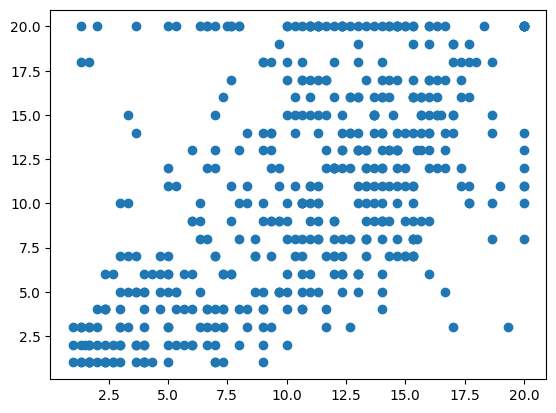

In [9]:
import matplotlib.pyplot as plt

plt.scatter(data2['RollingAverage3'], data2['Position'])

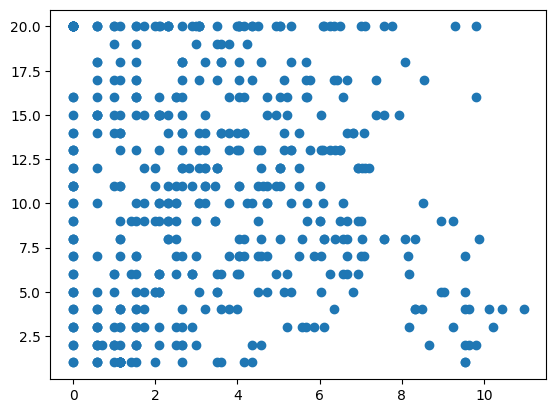

In [10]:
plt.scatter(data2['RollingStd3'], data2['Position'])

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('data/2025DataFrame.csv')

In [3]:
df

,DriverNumber,RoundNumber,Position,LastFinish,RollingAverage3,RollingStd3,FastestTime,Delta
0,1,1,2.0,NaN,2.000000,0.000000,75.481,0.385
1,1,2,4.0,2.0,2.000000,0.000000,90.817,0.176
2,1,3,1.0,4.0,3.000000,1.414214,86.983,0.000
3,1,4,6.0,1.0,2.333333,1.527525,90.423,0.582
4,1,5,2.0,6.0,3.666667,2.516611,87.294,0.000
...,...,...,...,...,...,...,...,...
474,87,20,4.0,9.0,10.000000,1.732051,76.460,0.874
475,87,21,6.0,4.0,7.333333,2.886751,69.755,0.244
476,87,22,10.0,6.0,6.333333,2.516611,113.094,5.160
477,87,23,20.0,10.0,6.666667,3.055050,80.438,1.051


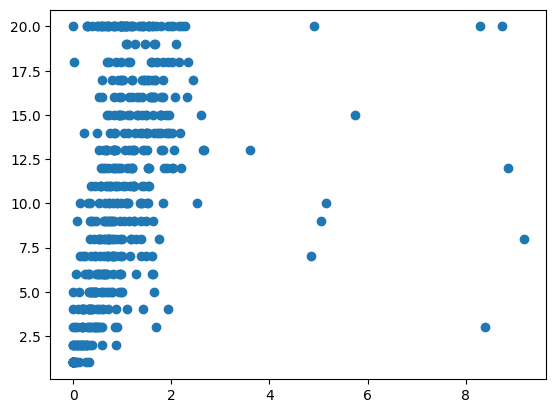

In [4]:
plt.scatter(df['Delta'], df['Position'])

Actually not a bad correlation. The best so far at least

In [5]:
from src.data_loading import get_season_qual_results
qual = get_season_qual_results(2025)
qual

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '4'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '1', '63', '22', '23', '16', '44', '10', '55', '6', '14', '18', '7', '5', '12', '27', '30', '31', '87']
core           INFO 	Loading dat

,DriverNumber,RoundNumber,Position
0,1,1,3.0
1,4,1,1.0
2,5,1,15.0
3,6,1,11.0
4,7,1,14.0
...,...,...,...
475,44,24,16.0
476,55,24,12.0
477,63,24,4.0
478,81,24,3.0


In [6]:
df2 = pd.merge(df, qual ,on=['DriverNumber', 'RoundNumber'], how='left')
df2

,DriverNumber,RoundNumber,Position_x,LastFinish,RollingAverage3,RollingStd3,FastestTime,Delta,Position_y
0,1,1,2.0,NaN,2.000000,0.000000,75.481,0.385,3.0
1,1,2,4.0,2.0,2.000000,0.000000,90.817,0.176,4.0
2,1,3,1.0,4.0,3.000000,1.414214,86.983,0.000,1.0
3,1,4,6.0,1.0,2.333333,1.527525,90.423,0.582,7.0
4,1,5,2.0,6.0,3.666667,2.516611,87.294,0.000,1.0
...,...,...,...,...,...,...,...,...,...
474,87,20,4.0,9.0,10.000000,1.732051,76.460,0.874,10.0
475,87,21,6.0,4.0,7.333333,2.886751,69.755,0.244,8.0
476,87,22,10.0,6.0,6.333333,2.516611,113.094,5.160,14.0
477,87,23,20.0,10.0,6.666667,3.055050,80.438,1.051,13.0


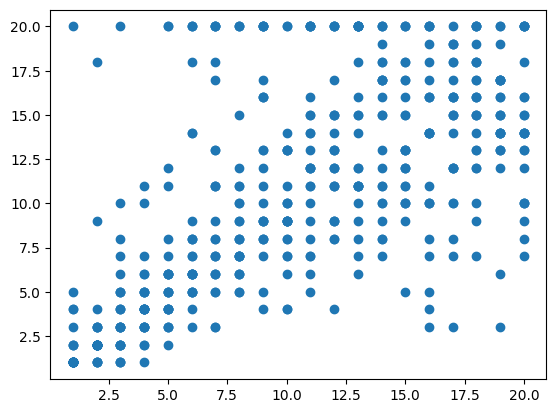

In [7]:
plt.scatter(df2['Position_y'], df2['Position_x'])

Now I want to try a model with all the data I have (except qualifying time) and then one with just qualifying position and delta

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('data/2025DataFrame.csv')
df

,DriverNumber,Season,RoundNumber,TeamName,Position,QualiPosition,FastestTime,LastFinish,RollingAverage3,RollingStd3,Delta
0,1,2025,1,Red Bull Racing,2.0,3.0,75.481,NaN,2.000000,0.000000,0.385
1,1,2025,2,Red Bull Racing,4.0,4.0,90.817,2.0,2.000000,0.000000,0.176
2,1,2025,3,Red Bull Racing,1.0,1.0,86.983,4.0,3.000000,1.414214,0.000
3,1,2025,4,Red Bull Racing,6.0,7.0,90.423,1.0,2.333333,1.527525,0.582
4,1,2025,5,Red Bull Racing,2.0,1.0,87.294,6.0,3.666667,2.516611,0.000
...,...,...,...,...,...,...,...,...,...,...,...
474,87,2025,20,Haas F1 Team,4.0,10.0,76.460,9.0,10.000000,1.732051,0.874
475,87,2025,21,Haas F1 Team,6.0,8.0,69.755,4.0,7.333333,2.886751,0.244
476,87,2025,22,Haas F1 Team,10.0,14.0,113.094,6.0,6.333333,2.516611,5.160
477,87,2025,23,Haas F1 Team,20.0,13.0,80.438,10.0,6.666667,3.055050,1.051


In [16]:
X = df[['DriverNumber', 'QualiPosition', 'LastFinish', 'RollingAverage3', 'RollingStd3', 'Delta']]
y = df['Position']
y

0       2.0
1       4.0
2       1.0
3       6.0
4       2.0
       ... 
474     4.0
475     6.0
476    10.0
477    20.0
478    12.0
Name: Position, Length: 479, dtype: float64

In [17]:
X['LastFinish'] = X['LastFinish'].astype(float)
X['LastFinish'][0]

C:\Users\jifor\AppData\Local\Temp\ipykernel_26760\3873788432.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['LastFinish'] = X['LastFinish'].astype(float)


np.float64(nan)

In [18]:
from sklearn.impute import SimpleImputer
import numpy as np

imputer = SimpleImputer(strategy='mean')
lastfinish = np.array(X['LastFinish'])
lastfinish = lastfinish.reshape(-1, 1)
X['LastFinish'] = imputer.fit_transform(lastfinish)
X
# lastfinish


C:\Users\jifor\AppData\Local\Temp\ipykernel_26760\1926071424.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['LastFinish'] = imputer.fit_transform(lastfinish)


,DriverNumber,QualiPosition,LastFinish,RollingAverage3,RollingStd3,Delta
0,1,3.0,10.611354,2.000000,0.000000,0.385
1,1,4.0,2.000000,2.000000,0.000000,0.176
2,1,1.0,4.000000,3.000000,1.414214,0.000
3,1,7.0,1.000000,2.333333,1.527525,0.582
4,1,1.0,6.000000,3.666667,2.516611,0.000
...,...,...,...,...,...,...
474,87,10.0,9.000000,10.000000,1.732051,0.874
475,87,8.0,4.000000,7.333333,2.886751,0.244
476,87,14.0,6.000000,6.333333,2.516611,5.160
477,87,13.0,10.000000,6.666667,3.055050,1.051


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)
X_train

,DriverNumber,QualiPosition,LastFinish,RollingAverage3,RollingStd3,Delta
160,14,11.0,7.0,12.000000,7.000000,1.157
462,87,17.0,17.0,16.666667,3.511885,2.025
288,27,13.0,8.0,14.666667,6.110101,1.430
56,5,12.0,14.0,17.333333,3.055050,1.210
68,5,20.0,10.0,15.000000,4.358899,NaN
...,...,...,...,...,...,...
290,27,11.0,9.0,12.333333,6.658328,4.847
51,5,18.0,19.0,17.666667,3.214550,2.345
310,30,12.0,5.0,10.333333,4.725816,1.162
86,6,4.0,11.0,17.000000,5.196152,0.546


In [20]:
model = RandomForestRegressor()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
predictions

array([15.26, 10.28, 14.29,  2.07, 14.47, 13.02, 14.21, 14.56,  8.28,
       13.91, 13.36, 13.09, 10.6 ,  3.01, 11.07,  7.52,  8.95, 16.83,
        4.13,  6.61, 11.55, 13.71, 15.16, 11.38, 14.04, 13.54,  2.94,
        1.75, 14.9 , 12.98, 13.1 ,  4.55,  9.8 , 10.46, 12.74, 14.7 ,
       13.99, 10.25,  7.46,  6.11,  7.67,  9.88, 13.44, 14.66, 13.3 ,
        3.69, 13.23,  9.83, 11.51, 10.3 , 11.77, 12.38,  2.17, 15.79,
       15.87,  7.94,  2.71, 11.95, 14.19, 14.08,  9.69,  7.96, 12.54,
       13.32, 14.1 , 16.53,  3.28,  2.35, 12.28, 13.19, 14.58, 11.59,
       14.45, 10.41, 14.62,  2.08, 15.02, 12.12, 13.78, 14.73, 11.61,
       15.19,  2.04,  1.98, 14.  , 13.62, 14.95, 12.37,  5.65,  6.65,
       12.39, 13.81, 11.23, 14.86, 14.89, 10.17])

In [21]:
y_test

59     20.0
270    15.0
330    16.0
16      1.0
325    16.0
       ... 
139    10.0
141     9.0
279     9.0
318     5.0
157    20.0
Name: Position, Length: 96, dtype: float64

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
error1 = mean_squared_error(y_test, predictions)
error2 = mean_absolute_error(y_test, predictions)
np.sqrt(error)
error2

3.65375

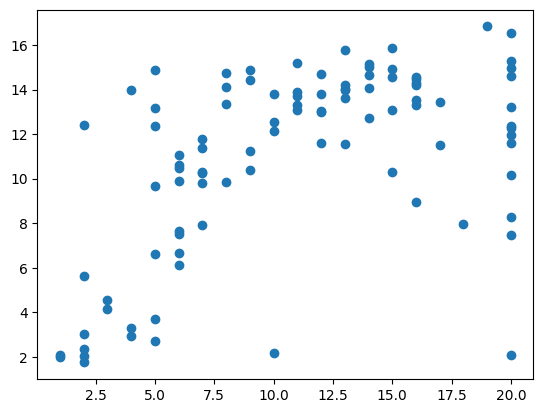

In [23]:
plt.scatter(y_test, predictions)

In [4]:
from src.model_training import train_RFR_model

model, predictions, error = train_RFR_model()

In [5]:
error

3.677604166666667

In [6]:
predictions

array([11.75, 13.75, 13.82, 12.71, 14.34, 14.56, 15.11, 13.92, 12.12,
       14.07, 13.66,  5.53, 12.17, 17.23, 10.13, 15.24,  2.98, 11.72,
       10.3 ,  3.23, 13.51, 14.99, 13.55, 13.02,  6.  ,  3.41, 13.34,
       11.22, 12.33,  1.72, 14.71,  8.21,  1.58, 14.48, 15.63, 14.14,
       12.82,  4.97,  3.08,  4.99, 12.2 , 11.  , 11.01,  3.56, 16.6 ,
       16.22, 12.9 ,  9.41,  3.78,  9.36, 16.68, 10.35,  3.11,  6.86,
       12.36,  8.01,  4.41,  1.14,  4.46, 14.51,  3.27, 17.48,  5.35,
       13.81,  1.78,  5.54,  9.76, 14.3 , 11.49, 12.07, 12.17,  5.08,
        3.24,  2.93, 10.87, 11.99,  5.03,  3.83, 13.06, 14.11,  8.24,
        5.5 , 16.01,  8.83,  7.96, 13.51, 14.19,  9.72, 10.24,  4.12,
        7.57, 15.41, 11.95,  9.2 ,  4.58, 12.07])

In [7]:
model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [8]:
import joblib
joblib.dump(model, 'model.pkl')

['model.pkl']

In [9]:
model2 = joblib.load('model.pkl')

In [11]:
import pandas as pd

df = pd.read_csv('data/F1_model_data.csv')
df.head()

,Unnamed: 0,DriverNumber,Season,RoundNumber,TeamName,Position,QualiPosition,FastestTime,LastFinish,RollingAverage3,RollingStd3,Delta
0,0,1,2025,1,Red Bull Racing,2.0,3.0,75.481,10.0,2.000000,0.000000,0.385
1,1,1,2025,2,Red Bull Racing,4.0,4.0,90.817,2.0,2.000000,0.000000,0.176
2,2,1,2025,3,Red Bull Racing,1.0,1.0,86.983,4.0,3.000000,1.414214,0.000
3,3,1,2025,4,Red Bull Racing,6.0,7.0,90.423,1.0,2.333333,1.527525,0.582
4,4,1,2025,5,Red Bull Racing,2.0,1.0,87.294,6.0,3.666667,2.516611,0.000


In [12]:
df.to_csv('data/F1_model_data.csv', index=False)

In [13]:
df.columns

Index(['Unnamed: 0', 'DriverNumber', 'Season', 'RoundNumber', 'TeamName',
       'Position', 'QualiPosition', 'FastestTime', 'LastFinish',
       'RollingAverage3', 'RollingStd3', 'Delta'],
      dtype='object')

In [14]:
df[df.columns]

,Unnamed: 0,DriverNumber,Season,RoundNumber,TeamName,Position,QualiPosition,FastestTime,LastFinish,RollingAverage3,RollingStd3,Delta
0,0,1,2025,1,Red Bull Racing,2.0,3.0,75.481,10.0,2.000000,0.000000,0.385
1,1,1,2025,2,Red Bull Racing,4.0,4.0,90.817,2.0,2.000000,0.000000,0.176
2,2,1,2025,3,Red Bull Racing,1.0,1.0,86.983,4.0,3.000000,1.414214,0.000
3,3,1,2025,4,Red Bull Racing,6.0,7.0,90.423,1.0,2.333333,1.527525,0.582
4,4,1,2025,5,Red Bull Racing,2.0,1.0,87.294,6.0,3.666667,2.516611,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...
474,474,87,2025,20,Haas F1 Team,4.0,10.0,76.460,9.0,10.000000,1.732051,0.874
475,475,87,2025,21,Haas F1 Team,6.0,8.0,69.755,4.0,7.333333,2.886751,0.244
476,476,87,2025,22,Haas F1 Team,10.0,14.0,113.094,6.0,6.333333,2.516611,5.160
477,477,87,2025,23,Haas F1 Team,20.0,13.0,80.438,10.0,6.666667,3.055050,1.051


In [15]:
type(df.columns)

pandas.core.indexes.base.Index

In [16]:
new_columns = df.columns.delete(0)
new_columns

Index(['DriverNumber', 'Season', 'RoundNumber', 'TeamName', 'Position',
       'QualiPosition', 'FastestTime', 'LastFinish', 'RollingAverage3',
       'RollingStd3', 'Delta'],
      dtype='object')

In [18]:
df[new_columns].to_csv('data/F1_model_data.csv', index=False)

In [19]:
df = pd.read_csv('data/F1_model_data.csv')
df.head()

,DriverNumber,Season,RoundNumber,TeamName,Position,QualiPosition,FastestTime,LastFinish,RollingAverage3,RollingStd3,Delta
0,1,2025,1,Red Bull Racing,2.0,3.0,75.481,10.0,2.000000,0.000000,0.385
1,1,2025,2,Red Bull Racing,4.0,4.0,90.817,2.0,2.000000,0.000000,0.176
2,1,2025,3,Red Bull Racing,1.0,1.0,86.983,4.0,3.000000,1.414214,0.000
3,1,2025,4,Red Bull Racing,6.0,7.0,90.423,1.0,2.333333,1.527525,0.582
4,1,2025,5,Red Bull Racing,2.0,1.0,87.294,6.0,3.666667,2.516611,0.000


In [21]:
X, y = df[['DriverNumber', 'QualiPosition', 'LastFinish', 'RollingAverage3', 'RollingStd3', 'Delta']], df['Position']
X.head()
y.head()

0    2.0
1    4.0
2    1.0
3    6.0
4    2.0
Name: Position, dtype: float64

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [23]:
model2

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [24]:
predictions2 = model2.predict(X_test)


In [25]:
predictions

array([11.75, 13.75, 13.82, 12.71, 14.34, 14.56, 15.11, 13.92, 12.12,
       14.07, 13.66,  5.53, 12.17, 17.23, 10.13, 15.24,  2.98, 11.72,
       10.3 ,  3.23, 13.51, 14.99, 13.55, 13.02,  6.  ,  3.41, 13.34,
       11.22, 12.33,  1.72, 14.71,  8.21,  1.58, 14.48, 15.63, 14.14,
       12.82,  4.97,  3.08,  4.99, 12.2 , 11.  , 11.01,  3.56, 16.6 ,
       16.22, 12.9 ,  9.41,  3.78,  9.36, 16.68, 10.35,  3.11,  6.86,
       12.36,  8.01,  4.41,  1.14,  4.46, 14.51,  3.27, 17.48,  5.35,
       13.81,  1.78,  5.54,  9.76, 14.3 , 11.49, 12.07, 12.17,  5.08,
        3.24,  2.93, 10.87, 11.99,  5.03,  3.83, 13.06, 14.11,  8.24,
        5.5 , 16.01,  8.83,  7.96, 13.51, 14.19,  9.72, 10.24,  4.12,
        7.57, 15.41, 11.95,  9.2 ,  4.58, 12.07])

In [26]:
predictions2

array([15.37,  8.01,  9.76, 11.2 , 15.09, 14.7 , 12.76, 12.14,  6.36,
       14.19, 16.87,  7.2 ,  5.93,  6.35, 16.6 ,  9.29, 12.25,  8.68,
       13.33,  9.24, 12.82, 14.65, 15.33, 10.24, 15.43, 11.95, 16.49,
       14.67,  1.17,  3.08,  3.5 , 14.67, 13.02,  9.64, 13.34, 18.17,
        2.41,  9.02,  5.12,  4.45, 14.81,  7.5 , 15.64, 12.43, 12.7 ,
        1.17,  5.03, 15.88, 15.54,  8.81, 18.26,  7.77,  7.62, 16.21,
       11.28,  1.01, 14.27, 16.77, 17.81, 12.8 , 12.94,  1.14,  7.36,
       16.54, 14.56,  5.12, 14.44, 11.06, 14.03, 12.49, 13.75,  8.83,
        1.6 , 10.92, 14.26,  9.62, 13.21, 19.2 ,  9.76, 11.67,  2.48,
        4.54, 12.62, 16.22,  5.84,  1.83, 12.57,  9.22,  1.47, 11.11,
       15.24, 16.6 , 15.83, 13.69, 16.06,  1.72,  3.23,  9.49, 15.23,
       15.7 , 13.73, 12.42, 13.82,  6.09,  6.81, 11.35, 10.92, 10.3 ,
       15.11, 15.65,  6.38,  4.05, 10.34,  3.45,  7.68, 12.  , 11.01,
        9.5 , 17.35, 14.97])

In [27]:
df.head()

,DriverNumber,Season,RoundNumber,TeamName,Position,QualiPosition,FastestTime,LastFinish,RollingAverage3,RollingStd3,Delta
0,1,2025,1,Red Bull Racing,2.0,3.0,75.481,10.0,2.000000,0.000000,0.385
1,1,2025,2,Red Bull Racing,4.0,4.0,90.817,2.0,2.000000,0.000000,0.176
2,1,2025,3,Red Bull Racing,1.0,1.0,86.983,4.0,3.000000,1.414214,0.000
3,1,2025,4,Red Bull Racing,6.0,7.0,90.423,1.0,2.333333,1.527525,0.582
4,1,2025,5,Red Bull Racing,2.0,1.0,87.294,6.0,3.666667,2.516611,0.000


In [29]:
X_teamnames = df[['DriverNumber', 'TeamName', 'QualiPosition', 'LastFinish', 'RollingAverage3', 'RollingStd3', 'Delta']]
y = df['Position']

X_teamnames.head()

,DriverNumber,TeamName,QualiPosition,LastFinish,RollingAverage3,RollingStd3,Delta
0,1,Red Bull Racing,3.0,10.0,2.000000,0.000000,0.385
1,1,Red Bull Racing,4.0,2.0,2.000000,0.000000,0.176
2,1,Red Bull Racing,1.0,4.0,3.000000,1.414214,0.000
3,1,Red Bull Racing,7.0,1.0,2.333333,1.527525,0.582
4,1,Red Bull Racing,1.0,6.0,3.666667,2.516611,0.000


In [30]:
X = pd.get_dummies(X_teamnames, columns=['TeamName'])
X.head()

,DriverNumber,QualiPosition,LastFinish,RollingAverage3,RollingStd3,Delta,TeamName_Alpine,TeamName_Aston Martin,TeamName_Ferrari,TeamName_Haas F1 Team,TeamName_Kick Sauber,TeamName_McLaren,TeamName_Mercedes,TeamName_Racing Bulls,TeamName_Red Bull Racing,TeamName_Williams
0,1,3.0,10.0,2.000000,0.000000,0.385,False,False,False,False,False,False,False,False,True,False
1,1,4.0,2.0,2.000000,0.000000,0.176,False,False,False,False,False,False,False,False,True,False
2,1,1.0,4.0,3.000000,1.414214,0.000,False,False,False,False,False,False,False,False,True,False
3,1,7.0,1.0,2.333333,1.527525,0.582,False,False,False,False,False,False,False,False,True,False
4,1,1.0,6.0,3.666667,2.516611,0.000,False,False,False,False,False,False,False,False,True,False


In [1]:
import pandas as pd

data = pd.read_csv('data/F1_model_data.csv')
data.head()

,DriverNumber,Season,RoundNumber,TeamName,Position,QualiPosition,FastestTime,LastFinish,RollingAverage3,RollingStd3,Delta
0,1,2025,1,Red Bull Racing,2.0,3.0,75.481,10.0,2.000000,0.000000,0.385
1,1,2025,2,Red Bull Racing,4.0,4.0,90.817,2.0,2.000000,0.000000,0.176
2,1,2025,3,Red Bull Racing,1.0,1.0,86.983,4.0,3.000000,1.414214,0.000
3,1,2025,4,Red Bull Racing,6.0,7.0,90.423,1.0,2.333333,1.527525,0.582
4,1,2025,5,Red Bull Racing,2.0,1.0,87.294,6.0,3.666667,2.516611,0.000


In [2]:
from src.model_training import train_RFR_model

model, X_test, y_test = train_RFR_model(data)

Model trained. Error of 3.4846875


In [3]:
predictions = model.predict(X_test)
predictions

array([ 3.41, 16.38, 14.02,  7.74, 13.15,  5.13,  9.92, 16.36, 12.09,
       16.32, 16.18, 10.58,  3.98, 13.55, 12.38,  4.16,  2.92, 12.45,
       13.81, 11.55, 11.45, 12.63, 13.68,  7.96,  5.64, 14.24, 12.87,
       11.43,  9.46, 13.11, 11.99,  5.18, 14.18, 12.51,  5.66, 13.16,
        6.79,  8.49,  8.7 ,  2.41,  9.8 ,  5.26, 14.73,  9.17, 11.09,
        7.23, 14.66, 12.86,  5.13, 15.46,  8.64, 15.42, 15.05,  5.72,
        8.29, 12.12, 13.4 ,  9.56, 11.77, 15.37, 10.25,  5.64,  7.02,
       13.6 , 11.98, 11.87, 12.21, 16.29, 14.48, 13.44,  7.58,  8.79,
       10.77,  8.86, 13.5 ,  8.53,  3.83, 14.98, 14.64, 10.36, 13.31,
        4.94, 14.39, 14.63,  5.59,  5.97, 10.63, 11.18,  3.89,  2.86,
       15.04, 12.95,  2.04, 11.05, 15.92, 14.65])

In [4]:
import joblib 

joblib.dump(model, 'model.pkl')

['model.pkl']

In [5]:
model2 = joblib.load('model.pkl')

In [6]:
p = model2.predict(X_test)
p

array([ 3.41, 16.38, 14.02,  7.74, 13.15,  5.13,  9.92, 16.36, 12.09,
       16.32, 16.18, 10.58,  3.98, 13.55, 12.38,  4.16,  2.92, 12.45,
       13.81, 11.55, 11.45, 12.63, 13.68,  7.96,  5.64, 14.24, 12.87,
       11.43,  9.46, 13.11, 11.99,  5.18, 14.18, 12.51,  5.66, 13.16,
        6.79,  8.49,  8.7 ,  2.41,  9.8 ,  5.26, 14.73,  9.17, 11.09,
        7.23, 14.66, 12.86,  5.13, 15.46,  8.64, 15.42, 15.05,  5.72,
        8.29, 12.12, 13.4 ,  9.56, 11.77, 15.37, 10.25,  5.64,  7.02,
       13.6 , 11.98, 11.87, 12.21, 16.29, 14.48, 13.44,  7.58,  8.79,
       10.77,  8.86, 13.5 ,  8.53,  3.83, 14.98, 14.64, 10.36, 13.31,
        4.94, 14.39, 14.63,  5.59,  5.97, 10.63, 11.18,  3.89,  2.86,
       15.04, 12.95,  2.04, 11.05, 15.92, 14.65])

In [1]:
import pandas as pd

data = pd.read_csv('data/F1_model_data.csv')
data.head()

,DriverNumber,Season,RoundNumber,TeamName,Position,QualiPosition,FastestTime,LastFinish,RollingAverage3,RollingStd3,Delta
0,1,2025,1,Red Bull Racing,2.0,3.0,75.481,10.0,2.000000,0.000000,0.385
1,1,2025,2,Red Bull Racing,4.0,4.0,90.817,2.0,2.000000,0.000000,0.176
2,1,2025,3,Red Bull Racing,1.0,1.0,86.983,4.0,3.000000,1.414214,0.000
3,1,2025,4,Red Bull Racing,6.0,7.0,90.423,1.0,2.333333,1.527525,0.582
4,1,2025,5,Red Bull Racing,2.0,1.0,87.294,6.0,3.666667,2.516611,0.000


In [2]:
feature_cols = ['DriverNumber', 'TeamName', 'QualiPosition', 'LastFinish', 'RollingAverage3', 'RollingStd3', 'Delta']
features = data[feature_cols]
features.head()

,DriverNumber,TeamName,QualiPosition,LastFinish,RollingAverage3,RollingStd3,Delta
0,1,Red Bull Racing,3.0,10.0,2.000000,0.000000,0.385
1,1,Red Bull Racing,4.0,2.0,2.000000,0.000000,0.176
2,1,Red Bull Racing,1.0,4.0,3.000000,1.414214,0.000
3,1,Red Bull Racing,7.0,1.0,2.333333,1.527525,0.582
4,1,Red Bull Racing,1.0,6.0,3.666667,2.516611,0.000


In [3]:
features = pd.get_dummies(features, columns=['TeamName'])
features.head()

,DriverNumber,QualiPosition,LastFinish,RollingAverage3,RollingStd3,Delta,TeamName_Alpine,TeamName_Aston Martin,TeamName_Ferrari,TeamName_Haas F1 Team,TeamName_Kick Sauber,TeamName_McLaren,TeamName_Mercedes,TeamName_Racing Bulls,TeamName_Red Bull Racing,TeamName_Williams
0,1,3.0,10.0,2.000000,0.000000,0.385,False,False,False,False,False,False,False,False,True,False
1,1,4.0,2.0,2.000000,0.000000,0.176,False,False,False,False,False,False,False,False,True,False
2,1,1.0,4.0,3.000000,1.414214,0.000,False,False,False,False,False,False,False,False,True,False
3,1,7.0,1.0,2.333333,1.527525,0.582,False,False,False,False,False,False,False,False,True,False
4,1,1.0,6.0,3.666667,2.516611,0.000,False,False,False,False,False,False,False,False,True,False


In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('data/Engineered_Data_2022_2025.csv')
data.head()

,DriverNumber,Season,RoundNumber,TeamName,Position,QualiPosition,FastestTime,LastFinish,RollingAverage3,RollingStd3,Delta
0,1,2022,1,Red Bull Racing,19.0,2.0,90.681,10.0,19.0,0.0,15.585
1,3,2022,1,McLaren,14.0,18.0,92.945,10.0,14.0,0.0,17.849
2,4,2022,1,McLaren,15.0,13.0,92.008,10.0,15.0,0.0,16.912
3,6,2022,1,Williams,16.0,20.0,93.634,10.0,16.0,0.0,18.538
4,10,2022,1,AlphaTauri,20.0,10.0,91.635,10.0,20.0,0.0,16.539


In [3]:
from src.model_training import train_RFR_model

model, X_test, y_test = train_RFR_model(data)

Model trained. Error of 3.703987473903967


In [4]:
predictions = model.predict(X_test)
predictions

array([ 5.16,  6.49, 15.92, 12.64, 15.18, 11.64, 11.2 , 11.67,  7.62,
       12.33,  6.79,  9.44, 16.11, 14.92, 15.78,  8.4 ,  6.91,  6.18,
        7.41, 15.02,  5.03,  4.58, 14.35,  9.66, 14.09, 13.2 ,  5.13,
       13.76,  6.71, 12.8 , 12.74, 12.58, 12.97, 12.93, 13.22,  6.47,
       13.6 ,  3.99,  6.16, 15.61,  2.24,  3.67, 16.35,  8.98, 15.42,
       12.24,  7.12, 13.62,  5.63, 15.34, 13.04, 12.04, 13.41, 13.94,
       13.91,  8.84, 10.17,  6.04,  6.16, 14.31,  5.24,  7.87, 14.99,
       12.05, 12.76, 10.93,  6.72, 12.74,  3.11, 16.28, 12.45, 13.57,
       15.54, 13.92, 13.75, 13.41,  9.69,  5.89,  4.49, 15.56,  2.34,
        9.79, 16.04, 14.3 , 15.94, 11.83,  7.13, 12.57,  5.05, 13.94,
       10.67, 12.18, 16.04, 13.99, 16.22,  6.19,  7.03,  5.85,  6.08,
       14.13,  1.97,  4.08, 14.45, 12.1 , 14.33, 15.32,  7.22, 10.82,
        7.19, 14.71, 14.23, 11.56, 14.71, 14.71, 10.95, 11.97,  6.82,
        6.02,  5.31, 14.71,  4.83,  4.14, 13.27, 11.78, 11.41,  8.92,
        7.38, 13.96,

In [5]:
import joblib
joblib.dump(model, 'model.pkl')

['model.pkl']

In [8]:
importances = model.feature_importances_

for name, val in zip(X_test.columns, importances):
    print(name, val)

DriverNumber 0.0512265952776622
QualiPosition 0.4392684723746933
LastFinish 0.08765178546594543
RollingAverage3 0.1205880579290582
RollingStd3 0.09555480737897522
Delta 0.126615297554993
TeamName_Alfa Romeo 0.004236938407307292
TeamName_AlphaTauri 0.0036137737708950204
TeamName_Alpine 0.008702343919813577
TeamName_Aston Martin 0.007160975060981933
TeamName_Ferrari 0.007669008148171511
TeamName_Haas F1 Team 0.007962144122387651
TeamName_Kick Sauber 0.0022255185399818345
TeamName_McLaren 0.005329341922701642
TeamName_Mercedes 0.012893821537392505
TeamName_RB 0.002943941124761282
TeamName_Red Bull Racing 0.011507479772182581
TeamName_Williams 0.00484969769209584
